# Question 1
You are given a list of n integers. Find and print the maximum and minimum values in the list without
using Python's built-in max() or min() functions.

In [6]:

nums = [12, 5, 78, 34, 1, 90, 23]

maximum = nums[0]
minimum = nums[0]

for num in nums:
    if num > maximum:
        maximum = num

    if num < minimum:
        minimum = num

print("Maximum:", maximum)
print("Minimum:", minimum)

Maximum: 90
Minimum: 1


# Question 2
Write a function that takes a string as input and returns whether it is a palindrome. The check should
be case-insensitive and should ignore spaces.

In [22]:

def is_palindrome(s):
    s = s.lower().replace(" ", "")
    return s == s[::-1]

text = "Never Odd Or Even"

if is_palindrome(text):
    print("Palindrome")
else:
    print("Not Palindrome")

Palindrome


# Question 3
You are given a list of n integers and a number x. Find and print any pair of elements from the list
whose absolute difference equals x. You are guaranteed that such a pair exists.

In [8]:

nums = [1, 5, 9, 14, 20]
x = 5

found = False

for i in range(len(nums)):
    for j in range(i + 1, len(nums)):

        if abs(nums[i] - nums[j]) == x:
            print("Pair found:", nums[i], nums[j])
            found = True
            break

    if found:
        break

Pair found: 9 14


## Question 4
**Load the following dictionary into a Pandas DataFrame:**

`data = {`
    `   'Ticker': ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'WIPRO'],`
    `   'Price': [2850.5, 3900.0, 1500.75, 1650.0, 420.3],`
    `   'Volume': [1200000, 850000, 1100000, 950000, 700000],`
    `   'Sector': ['Energy', 'IT', 'IT', 'Finance', 'IT']`
     `  }`

(a) Print the shape and the first 3 rows of the DataFrame.
(b) Print only the rows where Sector is 'IT'.
(c) Add a new column Market_Cap_Proxy = Price × Volume.
(d) Sort the DataFrame by Market_Cap_Proxy in descending order and print the result.

In [11]:

import pandas as pd

data = {
    'Ticker': ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'WIPRO'],
    'Price': [2850.5, 3900.0, 1500.75, 1650.0, 420.3],
    'Volume': [1200000, 850000, 1100000, 950000, 700000],
    'Sector': ['Energy', 'IT', 'IT', 'Finance', 'IT']
}

df = pd.DataFrame(data)

# (a)
print("Shape:", df.shape)
print(df.head(3))

# (b)
print("\nIT Sector Stocks:")
print(df[df['Sector'] == 'IT'])

# (c)
df['Market_Cap_Proxy'] = df['Price'] * df['Volume']

# (d)
sorted_df = df.sort_values(by='Market_Cap_Proxy', ascending=False)

print("\nSorted DataFrame:")
print(sorted_df)

Shape: (5, 4)
     Ticker    Price   Volume  Sector
0  RELIANCE  2850.50  1200000  Energy
1       TCS  3900.00   850000      IT
2      INFY  1500.75  1100000      IT

IT Sector Stocks:
  Ticker    Price   Volume Sector
1    TCS  3900.00   850000     IT
2   INFY  1500.75  1100000     IT
4  WIPRO   420.30   700000     IT

Sorted DataFrame:
     Ticker    Price   Volume   Sector  Market_Cap_Proxy
0  RELIANCE  2850.50  1200000   Energy      3.420600e+09
1       TCS  3900.00   850000       IT      3.315000e+09
2      INFY  1500.75  1100000       IT      1.650825e+09
3  HDFCBANK  1650.00   950000  Finance      1.567500e+09
4     WIPRO   420.30   700000       IT      2.942100e+08


# Question 5
Using the DataFrame from Question 4, answer the following:
(a) What is the mean price across all stocks?
(b) What is the total volume traded in the 'IT' sector?
(c) Which stock has the highest Market_Cap_Proxy? Print only its ticker name.

In [12]:

# (a)
mean_price = df['Price'].mean()
print("Mean Price:", mean_price)

# (b)
it_volume = df[df['Sector'] == 'IT']['Volume'].sum()
print("Total IT Volume:", it_volume)

# (c)
highest_stock = df.loc[df['Market_Cap_Proxy'].idxmax(), 'Ticker']

print("Highest Market Cap Proxy Stock:", highest_stock)

Mean Price: 2064.31
Total IT Volume: 2650000
Highest Market Cap Proxy Stock: RELIANCE


# Question 6
You are given the following NumPy array of exam scores for 8 students:
`scores = np.array([45, 82, 76, 55, 90, 38, 67, 71])`
(a) Compute the mean, median, and standard deviation of the scores.
(b) Normalize the array so all values fall between 0 and 1.
(c) Find the indices of students who scored above the mean.

In [13]:

import numpy as np

scores = np.array([45, 82, 76, 55, 90, 38, 67, 71])

# (a)
print("Mean:", np.mean(scores))
print("Median:", np.median(scores))
print("Standard Deviation:", np.std(scores))

# (b)
normalized = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

print("\nNormalized Scores:")
print(normalized)

# (c)
mean_score = np.mean(scores)

indices = np.where(scores > mean_score)

print("\nIndices Above Mean:")
print(indices)

Mean: 65.5
Median: 69.0
Standard Deviation: 16.963195453687373

Normalized Scores:
[0.13461538 0.84615385 0.73076923 0.32692308 1.         0.
 0.55769231 0.63461538]

Indices Above Mean:
(array([1, 2, 4, 6, 7]),)


# Question 7
Using NumPy, generate an array of 252 daily returns drawn from a normal distribution with mean
0.0008 and standard deviation 0.015. Then:
(a) Construct a price series starting at 100 by taking the cumulative product of (1 + daily return)
at each step.
(b) Plot the price series using Matplotlib with an appropriate title, x-axis label, and y-axis label.
(c) Print the final price, the peak price, and the maximum drawdown (the largest percentage drop
from a peak to a subsequent trough).

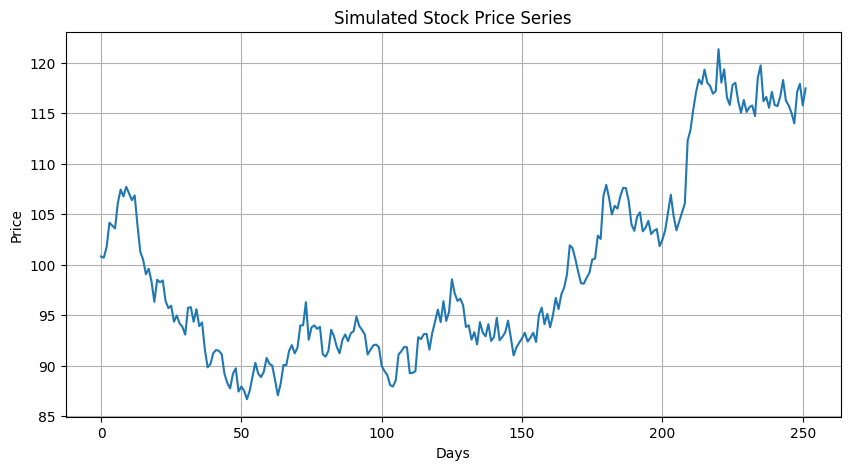

Final Price: 117.46716942863615
Peak Price: 121.34476107536163
Maximum Drawdown: -0.19526851119407773


In [14]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

returns = np.random.normal(0.0008, 0.015, 252)

prices = 100 * np.cumprod(1 + returns)

# (b)
plt.figure(figsize=(10, 5))

plt.plot(prices)

plt.title("Simulated Stock Price Series")
plt.xlabel("Days")
plt.ylabel("Price")

plt.grid(True)

plt.show()

# (c)
final_price = prices[-1]

peak_price = np.max(prices)

running_peak = np.maximum.accumulate(prices)

drawdown = (prices - running_peak) / running_peak

max_drawdown = np.min(drawdown)

print("Final Price:", final_price)
print("Peak Price:", peak_price)
print("Maximum Drawdown:", max_drawdown)

## Question 8
You are given the following monthly revenue data (in lakhs) for a fictional company across two years:
`months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']`
`year1 = [42, 45, 50, 48, 55, 60, 58, 63, 67, 70, 75, 80]`
`year2 = [52, 49, 58, 61, 66, 71, 68, 74, 79, 83, 88, 95]`
(a) Plot both years as separate lines on the same graph. Add a legend, title, and axis labels.
(b) Add a bar chart below the line chart (use subplots) showing the month-by-month difference
between Year 2 and Year 1 revenue. Color bars green if the difference is positive and red if
negative.

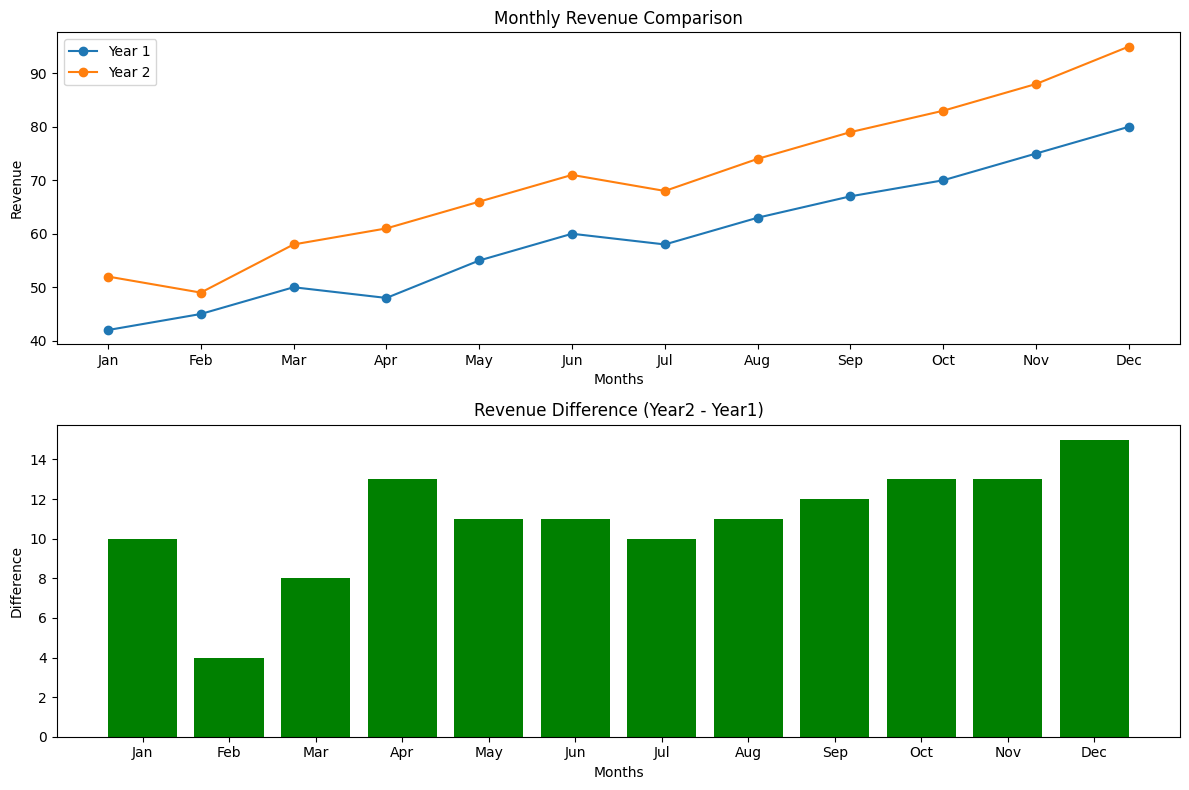

In [19]:

import matplotlib.pyplot as plt

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

year1 = [42, 45, 50, 48, 55, 60, 58, 63, 67, 70, 75, 80]

year2 = [52, 49, 58, 61, 66, 71, 68, 74, 79, 83, 88, 95]

difference = [y2 - y1 for y1, y2 in zip(year1, year2)]

colors = ['green' if d > 0 else 'red' for d in difference]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# (a)
axes[0].plot(months, year1, marker='o', label='Year 1')
axes[0].plot(months, year2, marker='o', label='Year 2')

axes[0].set_title("Monthly Revenue Comparison")
axes[0].set_xlabel("Months")
axes[0].set_ylabel("Revenue")

axes[0].legend()

# (b)
axes[1].bar(months, difference, color=colors)

axes[1].set_title("Revenue Difference (Year2 - Year1)")
axes[1].set_xlabel("Months")
axes[1].set_ylabel("Difference")

plt.tight_layout()

plt.show()

# Question 9
You are given the following dataset with some missing values:
`import numpy as np, pandas as pd`
`df = pd.DataFrame({'Day': range(1, 11),`
`'Price': [100, 103, np.nan, 108, 107, np.nan, 112, 115, np.nan, 120],`
`'Volume': [500, 520, 510, np.nan, 530, 545, np.nan, 560, 570, 580]`
`})`
(a) Identify how many missing values exist in each column.
(b) Fill missing Price values using forward fill, and missing Volume values using the column
mean.
(c) Compute the daily percentage return on Price as: (Price[t] - Price[t-1]) / Price[t-1] * 100. Add
this as a new column called Return.

In [20]:

import numpy as np
import pandas as pd

df = pd.DataFrame({
    'Day': range(1, 11),
    'Price': [100, 103, np.nan, 108, 107, np.nan, 112, 115, np.nan, 120],
    'Volume': [500, 520, 510, np.nan, 530, 545, np.nan, 560, 570, 580]
})

# (a)
print("Missing Values:")
print(df.isnull().sum())

# (b)
df['Price'] = df['Price'].ffill()

volume_mean = df['Volume'].mean()

df['Volume'] = df['Volume'].fillna(volume_mean)

# (c)
df['Return'] = df['Price'].pct_change() * 100

print("\nUpdated DataFrame:")
print(df)

Missing Values:
Day       0
Price     3
Volume    2
dtype: int64

Updated DataFrame:
   Day  Price   Volume    Return
0    1  100.0  500.000       NaN
1    2  103.0  520.000  3.000000
2    3  103.0  510.000  0.000000
3    4  108.0  539.375  4.854369
4    5  107.0  530.000 -0.925926
5    6  107.0  545.000  0.000000
6    7  112.0  539.375  4.672897
7    8  115.0  560.000  2.678571
8    9  115.0  570.000  0.000000
9   10  120.0  580.000  4.347826


# Question 10
You have price data for three assets over 200 trading days. Simulate it as follows:
`np.random.seed(42)`
`returns = np.random.multivariate_normal(`
`mean=[0.0005, 0.0008, 0.0003],`
`cov=[[0.0004, 0.0001, 0.00005],`
`[0.0001, 0.0006, 0.00008],`
`[0.00005, 0.00008, 0.0003]],`
`size=200`
`)`
`prices = 100 * np.cumprod(1 + returns, axis=0)`
(a) Convert the price array into a Pandas DataFrame with columns ['Asset_A', 'Asset_B',
'Asset_C'].
(b) Plot all three price series on the same chart with a legend.
(c) Compute the correlation matrix of daily returns across the three assets and print it.
(d) Construct an equally-weighted portfolio (1/3 each) and plot its value over time on the same
chart as (b).

     Asset_A    Asset_B     Asset_C
0  99.054490  98.884668  100.691921
1  97.322102  95.753775   99.296816
2  97.308181  91.876847   97.831242
3  96.265258  91.262457   96.659079
4  93.671756  92.654709   93.321190

Correlation Matrix:
          Asset_A   Asset_B   Asset_C
Asset_A  1.000000  0.086992  0.065127
Asset_B  0.086992  1.000000  0.200190
Asset_C  0.065127  0.200190  1.000000


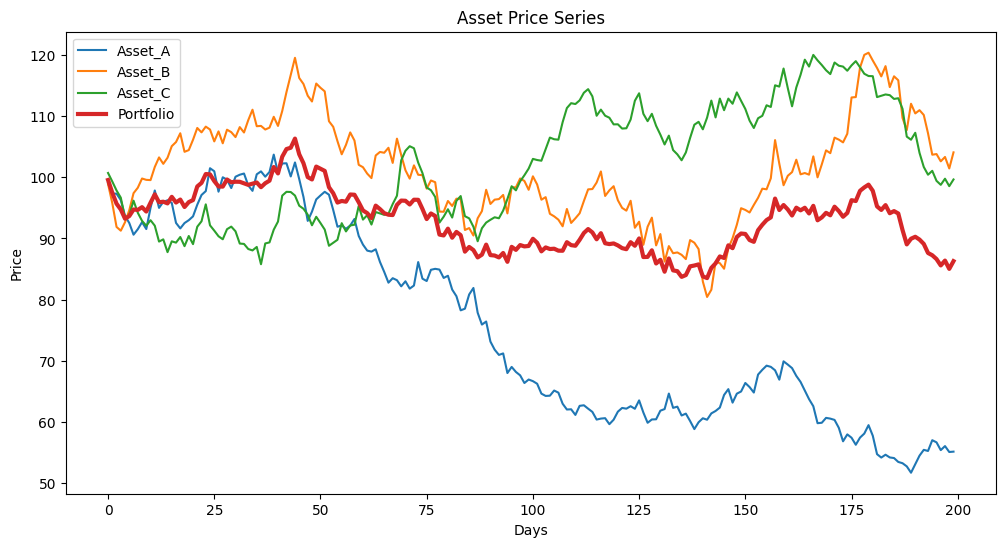

In [18]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

returns = np.random.multivariate_normal(
    mean=[0.0005, 0.0008, 0.0003],
    cov=[[0.0004, 0.0001, 0.00005],
         [0.0001, 0.0006, 0.00008],
         [0.00005, 0.00008, 0.0003]],
    size=200
)

prices = 100 * np.cumprod(1 + returns, axis=0)

# (a)
df_prices = pd.DataFrame(
    prices,
    columns=['Asset_A', 'Asset_B', 'Asset_C']
)

print(df_prices.head())

# (b)
plt.figure(figsize=(12, 6))

plt.plot(df_prices['Asset_A'], label='Asset_A')
plt.plot(df_prices['Asset_B'], label='Asset_B')
plt.plot(df_prices['Asset_C'], label='Asset_C')

plt.title("Asset Price Series")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()

# (c)
returns_df = df_prices.pct_change()

correlation_matrix = returns_df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# (d)
portfolio = df_prices.mean(axis=1)

plt.plot(portfolio, label='Portfolio', linewidth=3)

plt.legend()

plt.show()